<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->
# OSIRIS-REx Real Data — Media Corrections & Ramp Tables
---
*Scarabaeus OD Framework | Last revised 2026*

## What this notebook covers

This is a **standalone notebook on atmospheric media corrections and DSN ramp tables** using real OSIRIS-REx tracking data.  These auxiliary data products must be applied to raw radiometric observables before they enter any orbit determination filter.

| # | Topic |
|---|-------|
| 1 | Setup — units, frames, SPICE kernels, ground stations |
| 2 | Tropospheric delay models — seasonal and non-seasonal components |
| 3 | DSN ramp table inspection and integrated frequency sensitivity |
| 4 | Full RTLT media correction pipeline applied to real sequential ranging data |

## See Also
- [OSIRIS-REx OD Notebook](advanced_RealMSR_OSIRIS_REx_OD.ipynb) — applies these corrections inside a full SRIF filter run

## 1. Setup

Standard scientific imports plus `scarabaeus` and the tutorial `supplementary` helper.  Units and frames are created once here and reused throughout all sections.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import supplementary as supp
import scarabaeus as scb

kg, km, sec, unitless = scb.Units.get_units(["kg", "km", "sec", "unitless"])
(J2000, ITRF93, ECLIPJ2000, IAUEARTH) = scb.Frame.generate_common_frames()

plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8,
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--',
})

## 1.1 — SPICE Kernels and Ground Stations

`supp.load_data()` ensures all tutorial data files are present, downloading or generating anything missing.  `load_kernel_from_mkfile()` furnishes the complete OSIRIS-REx kernel set (SPK trajectories, PCK body constants, LSK leap-second, and frame kernels).

Three DSN complexes are used throughout this notebook:

| Variable | DSN ID | Complex | Location |
|---|---|---|---|
| `GS_C10` | DSS-24 | Goldstone | California, USA |
| `GS_C40` | DSS-35 | Canberra | Australia |
| `GS_C60` | DSS-65 | Madrid | Spain |

In [2]:
# load tutorial data
data = supp.load_data()

# load kernels
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(data.OREx_real_data_mk.path)

# Ground stations (one per DSN complex)
GS_C10 = scb.GroundStation("DSS-24")  # Goldstone, California
GS_C40 = scb.GroundStation("DSS-35")  # Canberra, Australia
GS_C60 = scb.GroundStation("DSS-65")  # Madrid, Spain


SCB supplementary data up to date.


---
## 2. Tropospheric Delay Models

Radio signals passing through Earth's troposphere acquire a **non-dispersive path-length delay**.

SCB decomposes the zenith tropospheric delay into two additive components, each stored in a separate JSON file:

| Component | File pattern | Model |
|---|---|---|
| **Seasonal** | `1972_001_2048_001_tro_modified.json` | `mediafun_trig` — trigonometric annual + semi-annual fit |
| **Non-seasonal** | `YYYY_DDD_YYYY_DDD_tro.json` | `mediafun_nrmpow` — normalized power-law fit |

Both files are nested by site (`C10`, `C40`, `C60`) and wet/dry component.  `MediaCorrections.get_media_data_for_et()` retrieves the coefficient block that brackets any query epoch.

### 2.1 — Single-station, single-component query

The simplest usage: one station, one epoch, one component (wet or dry).

1. Load the correction JSON and convert the UTC query time to SPICE ET.
2. Call `get_media_data_for_et()` to retrieve the bracketing coefficient dictionary.
3. Pass it to the appropriate model — `mediafun_trig` (seasonal) or `mediafun_nrmpow` (non-seasonal) — which returns the zenith delay in **meters**.

In [3]:
# load tutorial data
data = supp.load_data()

# load kernels
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(data.OREx_real_data_mk.path)

# Load tropospheric correction files

tropo_seasonal_path = data.tropo_seasonal_new.path
tropo_nonseasonal_path = data.tropo_nonseasonal.path

#tropo_seasonal_path    = "data/measurements/media_correction/1972_001_2048_001_tro_modified.json"
#tropo_nonseasonal_path = "data/measurements/media_correction/2010_001_2010_032_tro.json"

tropo_seasonal_dict = scb.Utils.load_json(tropo_seasonal_path)
tropo_dict          = scb.Utils.load_json(tropo_nonseasonal_path)

# Query parameters
query_utc      = "2010-01-15 00:07:00 UTC"
query_site     = "C60"   # "C10" | "C40" | "C60"
query_wetordry = "DRY"   # "DRY" | "WET"

# Convert UTC to SPICE ephemeris time
query_et = scb.SpiceManager.utc2et(query_utc)

# Retrieve coefficient sub-dictionaries for the query epoch
aux_seasonal     = scb.MediaCorrections.get_media_data_for_et(
    tropo_seasonal_dict["aux_tropo"], query_site, query_wetordry, query_et
)
aux_non_seasonal = scb.MediaCorrections.get_media_data_for_et(
    tropo_dict["aux_tropo"], query_site, query_wetordry, query_et
)

# Evaluate delay models (result in meters)
delta_m_seasonal     = scb.MediaCorrections.mediafun_trig(aux_seasonal, query_et)
delta_m_non_seasonal = scb.MediaCorrections.mediafun_nrmpow(aux_non_seasonal, query_et)

print(f"Query:              {query_utc}  |  Site: {query_site}  |  Component: {query_wetordry}")
print(f"Seasonal delay:     {delta_m_seasonal:.6f} m")
print(f"Non-seasonal delay: {delta_m_non_seasonal:.6f} m")
print(f"Total zenith delay: {delta_m_seasonal + delta_m_non_seasonal:.6f} m")

SCB supplementary data up to date.
Query:              2010-01-15 00:07:00 UTC  |  Site: C60  |  Component: DRY
Seasonal delay:     2.118438 m
Non-seasonal delay: -0.012684 m
Total zenith delay: 2.105753 m


### 2.2 — Multi-station time-series

A nested loop evaluates the delay at 1 000 evenly spaced epochs over January–February 2010 for all three sites and both wet/dry components.  A guard (`if aux_data else 0.0`) handles epochs outside the file's coverage window.

The plots overlay the **seasonal-only** curve against the **seasonal + non-seasonal** total, making the non-seasonal residual visually apparent.

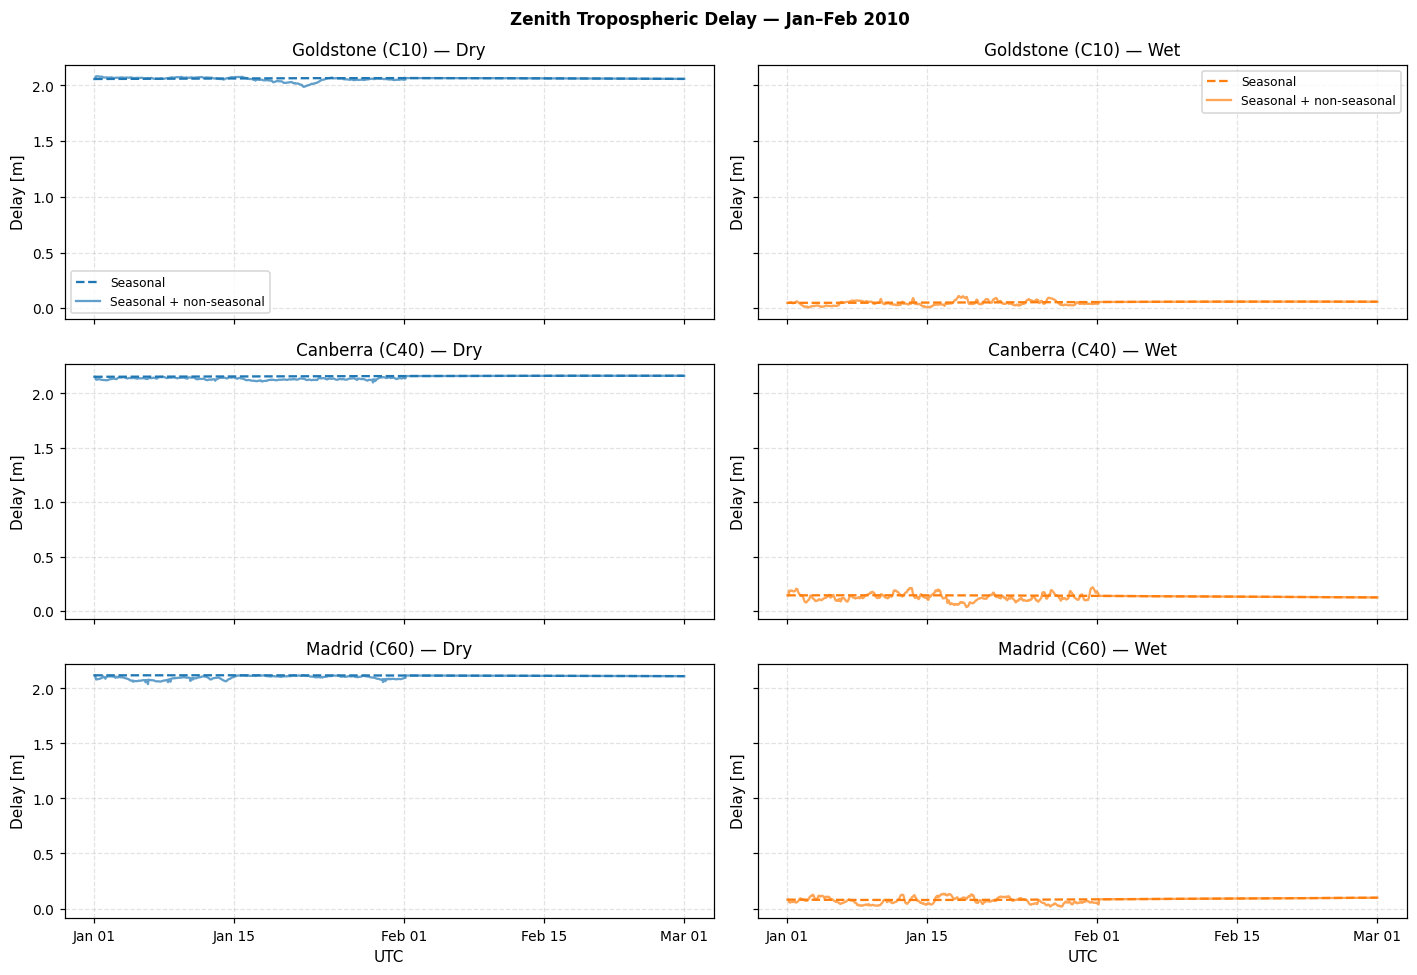

In [4]:
import datetime
import matplotlib.dates as mdates

def et_to_utc(et_arr):
    """Convert array of SPICE ET values to list of UTC datetime objects."""
    return [datetime.datetime.fromisoformat(str(scb.SpiceManager.et2utc(et))[:19])
            for et in et_arr]

def fmt_cal(ax, fmt="%b %d"):
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))

# Time span: Jan 1 – Feb 28, 2010
t_start_et  = scb.SpiceManager.utc2et("2010-01-01 00:00:00 UTC")
t_end_et    = scb.SpiceManager.utc2et("2010-02-28 23:59:00 UTC")
timespan_et = np.linspace(t_start_et, t_end_et, 1000)
timespan_utc = et_to_utc(timespan_et)

queries_site    = ["C10", "C40", "C60"]
queries_wetdry  = ["DRY", "WET"]
S, W, T = len(queries_site), len(queries_wetdry), len(timespan_et)

delta_m_seasonal     = np.zeros((S, W, T))
delta_m_non_seasonal = np.zeros((S, W, T))

for si, site in enumerate(queries_site):
    for wi, wd in enumerate(queries_wetdry):
        for ti, et in enumerate(timespan_et):
            aux_s = scb.MediaCorrections.get_media_data_for_et(
                tropo_seasonal_dict["aux_tropo"], site, wd, et
            )
            aux_n = scb.MediaCorrections.get_media_data_for_et(
                tropo_dict["aux_tropo"], site, wd, et
            )
            delta_m_seasonal[si, wi, ti]     = scb.MediaCorrections.mediafun_trig(aux_s, et)     if aux_s else 0.0
            delta_m_non_seasonal[si, wi, ti] = scb.MediaCorrections.mediafun_nrmpow(aux_n, et)   if aux_n else 0.0

site_labels = {"C10": "Goldstone (C10)", "C40": "Canberra (C40)", "C60": "Madrid (C60)"}
wd_labels   = {"DRY": "Dry", "WET": "Wet"}
colors      = ["C0", "C1"]

fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True, sharey="row")
fig.suptitle("Zenith Tropospheric Delay — Jan–Feb 2010", fontweight="bold", fontsize=11)

for si, site in enumerate(queries_site):
    for wi, wd in enumerate(queries_wetdry):
        ax = axes[si, wi]
        total = delta_m_non_seasonal[si, wi, :] + delta_m_seasonal[si, wi, :]
        ax.plot(timespan_utc, delta_m_seasonal[si, wi, :],
                lw=1.5, ls="--", color=colors[wi], label="Seasonal")
        ax.plot(timespan_utc, total,
                lw=1.5, ls="-",  color=colors[wi], alpha=0.7, label="Seasonal + non-seasonal")
        ax.set_title(f"{site_labels[site]} — {wd_labels[wd]}")
        ax.set_ylabel("Delay [m]")
        fmt_cal(ax)
        if si == 2:
            ax.set_xlabel("UTC")
        if si == 0:
            ax.legend()

plt.tight_layout()
plt.show()

### 2.3 — Elevation mapping function

The zenith delay applies only when the signal travels straight up.  For a real link at elevation angle $E$, the slant delay is:

$$\delta_s = m(E) \cdot \delta_z$$

SCB implements the **Chao (1972)** mapping function via `MediaCorrections.chao_mapping(elevation_rad)`, which returns separate dry and wet factors.  Both approach 1 at zenith (90°) and grow steeply near the horizon.

> **Note:** Measurements below ~15° elevation are typically rejected in OD processing — the mapping function uncertainty and multipath contamination become unacceptably large.

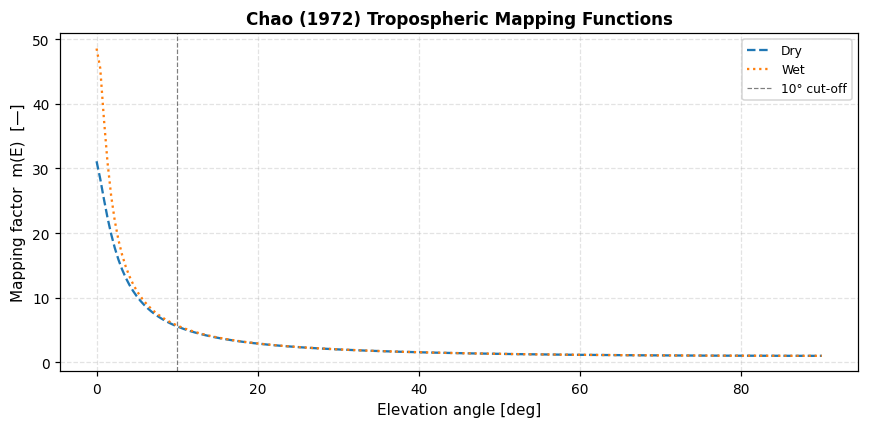

In [5]:
# Evaluate Chao mapping functions over full elevation range
E_rad = np.linspace(0, np.pi / 2, 200)
dry_mapping = np.empty_like(E_rad)
wet_mapping = np.empty_like(E_rad)

for i, el in enumerate(E_rad):
    dry_mapping[i], wet_mapping[i] = scb.MediaCorrections.chao_mapping(el)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(E_rad), dry_mapping, lw=1.5, ls="--", color="C0", label="Dry")
ax.plot(np.degrees(E_rad), wet_mapping, lw=1.5, ls=":",  color="C1", label="Wet")
ax.axvline(10, color="k", lw=0.8, ls="--", alpha=0.5, label="10° cut-off")
ax.set_xlabel("Elevation angle [deg]")
ax.set_ylabel("Mapping factor  m(E)  [—]")
ax.set_title("Chao (1972) Tropospheric Mapping Functions", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. DSN Ramp Tables

DSN uplink signals are not always transmitted at a constant frequency.  When a **frequency ramp** is in effect, the exciter follows a pre-programmed schedule stored in the tracking data as SFDU record type 9.

| Field | Description |
|---|---|
| `sec` | Second-of-day at which the ramp interval begins |
| `doy` | Day-of-year of the ramp interval |
| `ramp_freq` | Exciter frequency at interval start [Hz] |
| `ramp_rate` | Linear frequency rate during the interval [Hz/s] |
| `ramp_type` | Integer flag identifying the ramp mode |

`scb.RampTableManager.integrate(ramp_data, t1_sec, t3_sec, t1_doy, t3_doy)` integrates the piecewise-linear frequency profile between two epochs and returns the total accumulated phase — required to convert a sequential ranging observable to a time-of-flight when the uplink is ramped.

### 3.1 — Loading and inspecting ramp table data

The ramp table lives in the `aux_SFDU_9` block of the tracking JSON file.  Its five fields are assembled into the list format expected by `RampTableManager.integrate()`.

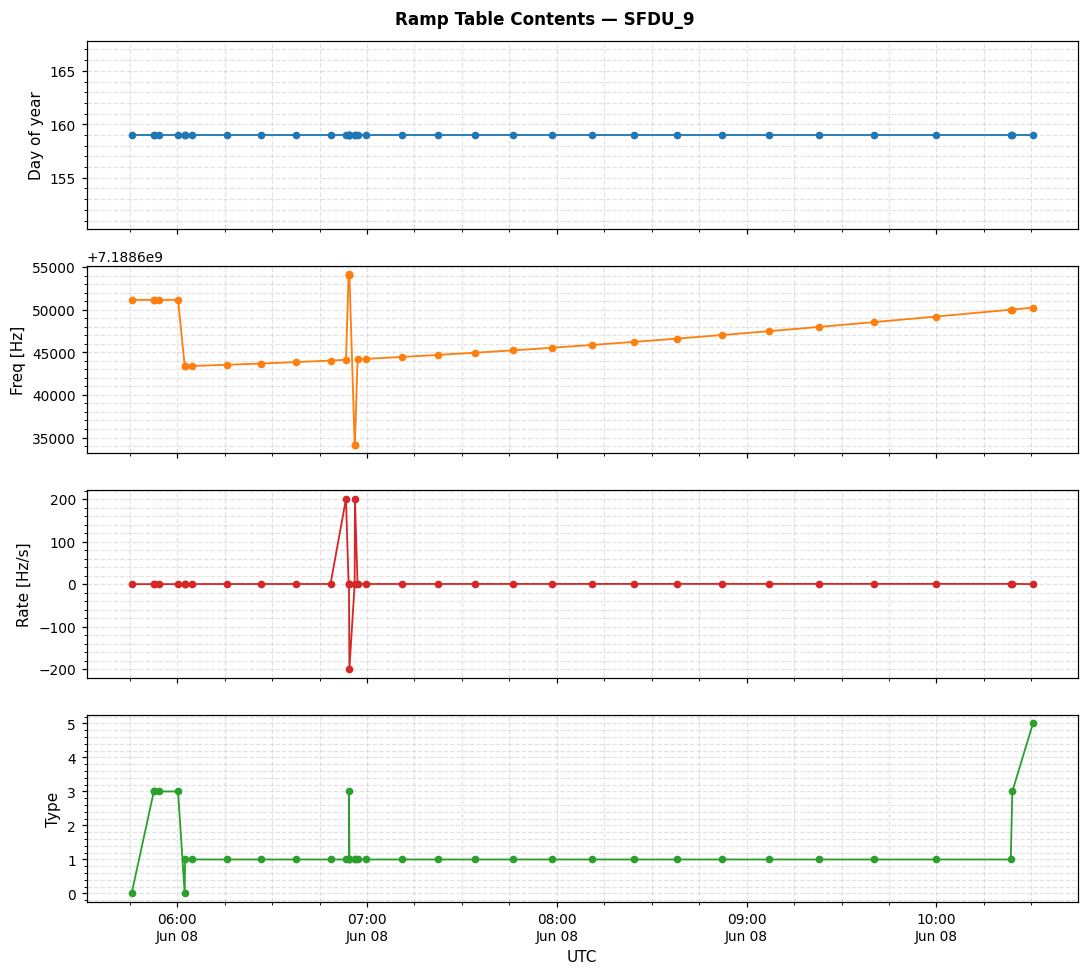

In [6]:
trk_file_path = data.trk_file.path
trk_data  = scb.Utils.load_json(trk_file_path)

# Assemble ramp table list in the format expected by RampTableManager
ramp_data = [
    trk_data["aux_SFDU_9"]["sec"],
    trk_data["aux_SFDU_9"]["doy"],
    trk_data["aux_SFDU_9"]["ramp_freq"],
    trk_data["aux_SFDU_9"]["ramp_rate"],
    trk_data["aux_SFDU_9"]["ramp_type"],
]

s9       = trk_data["aux_SFDU_9"]
# Convert seconds-of-day to UTC datetimes (pass date: 2018 DoY 159 = Jun 8)
_day0    = datetime.datetime(int(s9["year"][0]), 1, 1) + datetime.timedelta(days=int(s9["doy"][0]) - 1)
ramp_utc = [_day0 + datetime.timedelta(seconds=float(s)) for s in s9["sec"]]

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
fig.suptitle("Ramp Table Contents — SFDU_9", fontweight="bold", fontsize=11)

axes[0].plot(ramp_utc, s9["doy"],       "C0o-", ms=4, lw=1.2); axes[0].set_ylabel("Day of year")
axes[1].plot(ramp_utc, s9["ramp_freq"], "C1o-", ms=4, lw=1.2); axes[1].set_ylabel("Freq [Hz]")
axes[2].plot(ramp_utc, s9["ramp_rate"], "C3o-", ms=4, lw=1.2); axes[2].set_ylabel("Rate [Hz/s]")
axes[3].plot(ramp_utc, s9["ramp_type"], "C2o-", ms=4, lw=1.2); axes[3].set_ylabel("Type")
axes[3].set_xlabel("UTC")

for ax in axes:
    ax.minorticks_on()
    ax.grid(True, which="both", alpha=0.35, linestyle="--")
    fmt_cal(ax, fmt="%H:%M\n%b %d")

plt.tight_layout()
plt.show()

### 3.2 — Integrated frequency sensitivity

`RampTableManager.integrate()` is evaluated at 13 logarithmically spaced offsets from `t1`, spanning nanoseconds to thousands of seconds.  The result is scaled by the Range Unit (RU) conversion factor, giving accumulated phase in RU as a function of count interval.

> **Key insight:** On a log-log scale, a slope of 1 means the uplink frequency is approximately constant over that interval — the ramp rate is negligible at that timescale.

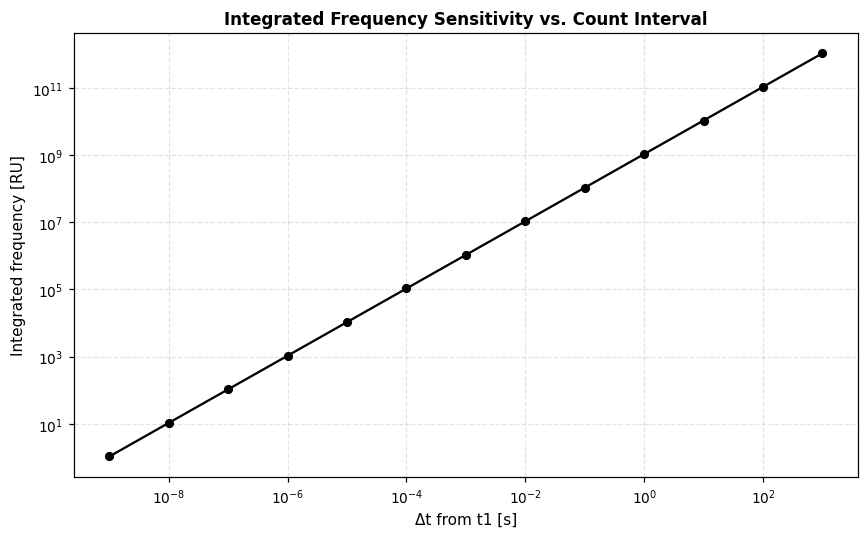

In [7]:
# Constants derived from the loaded ramp table
# Skip ramp_type=0 entries — the integrator treats them as inactive intervals
s9         = trk_data["aux_SFDU_9"]
valid_idx  = next(i for i, rt in enumerate(s9["ramp_type"]) if rt != 0)
RU         = 0.147530040053405          # Range Unit conversion factor (OREX X-band)
t1_sec     = s9["sec"][valid_idx]       # First active ramp epoch (sec of day)
t1_doy     = int(s9["doy"][valid_idx])
t3_doy     = t1_doy
delta_t    = 10 ** np.arange(-9, 4, dtype=float)   # 13 log-spaced offsets [s]

f_int_RU = []
for dt in delta_t:
    f_int, _ = scb.RampTableManager.integrate(ramp_data, t1_sec, t1_sec + dt, t1_doy, t3_doy)
    f_int_RU.append(RU * f_int)

f_int_RU = np.array(f_int_RU)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(delta_t, f_int_RU, "ko-", ms=5, lw=1.5)
ax.set_xlabel("Δt from t1 [s]")
ax.set_ylabel("Integrated frequency [RU]")
ax.set_title("Integrated Frequency Sensitivity vs. Count Interval", fontweight="bold")
ax.grid(True, which="both", alpha=0.35, linestyle="--")
ax.minorticks_on()
plt.tight_layout()
plt.show()

---
## 4. RTLT Media Corrections for Sequential Ranging

The zenith delay from Section 2 must be projected into the actual **round-trip light-time (RTLT)** geometry of a two-way pass.  The full pipeline is:

| Step | Action |
|---|---|
| 1 | Load a tracking data file; identify the ground station |
| 2 | Extract receive epochs `t3` from the sequential ranging observable |
| 3 | Estimate transmit epochs `t1` via a two-step SPICE light-time computation |
| 4 | Evaluate `computed_rtlt_delays()` at both `t1` (uplink) and `t3` (downlink) |
| 5 | Sum the two one-way delays to get the total RTLT path-length correction |
| 6 | Convert: meters → seconds → Range Units |

The corrected delay is subtracted from the raw observable before it enters the OD filter.

### 4.1 — Load tracking data and set up the ground station

The tracking file is a two-way pass from **DSS-35 (Canberra)** acquired on 2018 day-of-year 159.  It contains both sequential ranging (`2W_sranging`) and Doppler (`2W_doppler`) observables; only the ranging measurements are processed here.

`MediaCorrections` is constructed with the ground station and the seasonal correction file.  The non-seasonal file is resolved automatically in Section 4.3 once the pass date is known.

In [8]:
trk_file_path       = data.trk_file.path
tropo_seasonal_path = data.tropo_seasonal_new.path
tropo_file_bucket   = os.path.dirname(data.tropo_nonseasonal.path)

# Read tracking data and identify the ground station
trk_data = scb.Utils.load_json(trk_file_path)
DSS_name = "DSS-" + str(trk_data["2W_doppler"]["spice_id"][0])
GS1 = scb.GroundStation(DSS_name)
print("Ground station:", DSS_name)

# Build the uplink frequency array from the ramp table (used for RU conversion)
uplink_carrier_df  = pd.DataFrame.from_dict(trk_data["aux_SFDU_0"], orient="index").transpose()
frequency_values   = pd.Series(uplink_carrier_df["ramp_freq"].reset_index(drop=True))
frequency_array    = scb.ArrayWUnits(np.array(frequency_values), sec**-1)

# Create MediaCorrections object (seasonal file loaded now; non-seasonal set in 4.3)
media_correction = scb.MediaCorrections(
    name="GS1 SRA Media Corrections",
    instrument=GS1,
    tropo_seasonal_file_path=tropo_seasonal_path,
)

# Create the sequential ranging model and extract observed t3 epochs
SRA_model = scb.SequentialRangingReal("GS1 SRA Model", GS1)
SRA_t3, meas_sec, meas_obs, meas_outliers = SRA_model.observed_measurements(
    trk_file_path, meas_name="2W_sranging"
)
print(f"Sequential ranging observations: {len(SRA_t3.times.values)}")

Ground station: DSS-35


Sequential ranging observations: 99


### 4.2 — Compute transmit epochs t1

Sequential ranging observables are tagged at the **receive time** `t3`.  The transmit time `t1` is estimated in two SPICE steps:

1. Compute the **downlink** one-way light time at `t3` (spacecraft → ground).
2. Subtract from `t3` to approximate the spacecraft reception time; compute the **uplink** one-way light time (ground → spacecraft) at that epoch.
3. `RTLT = t_uplink + t_downlink`,  `t1 = t3 − RTLT`.

In [9]:
target = "-64"   # OSIRIS-REx NAIF ID
frame  = ITRF93

# Downlink one-way light time: spacecraft → ground at t3
dl_rtlt = scb.SpiceManager.get_lighttime(
    trgt_bdy=target,
    epoch_time=SRA_t3.times.values,
    reference_frame=frame.name,
    obsvr_bdy=GS1.name,
    aberration_correction="CN+S",
)

# Uplink one-way light time: ground → spacecraft (at the epoch when signal arrived)
ul_rtlt = scb.SpiceManager.get_lighttime(
    trgt_bdy=GS1.name,
    epoch_time=SRA_t3.times.values - dl_rtlt.values,
    reference_frame=frame.name,
    obsvr_bdy=target,
    aberration_correction="CN+S",
)

rtlt              = ul_rtlt.values + dl_rtlt.values
SRA_t1_array      = SRA_t3.times.values - rtlt
SRA_t1_epoch      = scb.EpochArray(SRA_t1_array, sys="TDB")

print(f"Mean RTLT: {np.mean(rtlt)/60:.2f} min  |  Range: [{np.min(rtlt)/60:.2f}, {np.max(rtlt)/60:.2f}] min")

Mean RTLT: 6.08 min  |  Range: [6.07, 6.08] min


### 4.3 — Resolve the non-seasonal file and compute elevation angles

`MediaCorrections.find_tro_metadata()` scans the correction file directory and returns the file whose coverage window brackets the pass date (extracted from the first `t3` epoch).

Elevation angles at each `t3` are computed with `SpiceManager.get_elevation_angle()`.  They drive the Chao mapping function and serve as a diagnostic — passes near the horizon carry larger and more uncertain corrections.

In [10]:
# Find the non-seasonal correction file for this pass
year_q, day_q, _ = scb.SpiceManager.et2YDS([SRA_t3.times.values[0]])
metadata_tropo = scb.MediaCorrections.find_tro_metadata(tropo_file_bucket, year_q[0], day_q[0])
media_correction.tropo_non_seasonal_file_path = os.path.join(
    tropo_file_bucket, metadata_tropo["file"]
)
print("Non-seasonal file:", metadata_tropo["file"])

# Elevation angles at each t3 epoch
rad_unit = scb.Units.get_units(["rad"])
SRA_elevation_angles = []
for et in SRA_t3.times.values:
    el_awu = scb.SpiceManager.get_elevation_angle(
        target=target,
        et=et,
        station=DSS_name,
        abcorr="LT+S",
    )
    el_rad = scb.ArrayWUnits.get_value_in_target_units(el_awu, rad_unit)
    SRA_elevation_angles.append(np.degrees(el_rad))

SRA_elevation_angles = np.array(SRA_elevation_angles)
print(f"Elevation angle range: {SRA_elevation_angles.min():.1f}° – {SRA_elevation_angles.max():.1f}°")

Non-seasonal file: 2018_152_2018_182_tro.json
Elevation angle range: 30.1° – 82.2°


### 4.4 — Compute RTLT tropospheric delays

`computed_rtlt_delays()` evaluates the full model (seasonal + non-seasonal, dry + wet, Chao-mapped) at a given ET and returns the one-way path-length correction in **meters**.  The RTLT correction and unit chain are:

$$
\Delta p\,[\mathrm{m}] = \Delta p(t_3) + \Delta p(t_1)
\qquad
\Delta\tau\,[\mathrm{s}] = \frac{\Delta p \times 10^{-3}}{c}
\qquad
\Delta\Phi\,[\mathrm{RU}] = \Delta\tau \cdot f_\mathrm{uplink}
$$

where $c$ is the speed of light in km/s (`scb.constants.c`) and the factor $10^{-3}$ converts meters to kilometres.

In [11]:
SRA_tropo_t3 = []
SRA_tropo_t1 = []

for ii in range(len(SRA_t3.times.values)):
    t3 = SRA_t3.times.values[ii]
    t1 = SRA_t1_epoch.times.values[ii]

    p_t3 = media_correction.computed_rtlt_delays(query_time_et=t3, target_spice_id=target)
    p_t1 = media_correction.computed_rtlt_delays(query_time_et=t1, target_spice_id=target)

    SRA_tropo_t3.append(p_t3)
    SRA_tropo_t1.append(p_t1)

SRA_tropo_t3 = np.array(SRA_tropo_t3)
SRA_tropo_t1 = np.array(SRA_tropo_t1)

# RTLT path-length correction [m]
SRA_delta_m    = SRA_tropo_t3 + SRA_tropo_t1

# Convert to RTLT time correction [s]  (Moyer 10-27: 1e-3 converts m → km)
SRA_delta_rtlt = (1.0 / scb.constants.c.values) * (SRA_delta_m * 1e-3)

# Convert to Range Units
SRA_delta_RU   = SRA_delta_rtlt * frequency_array[0].values

print(f"Mean RTLT tropo correction: {np.mean(SRA_delta_rtlt)*1e6:.3f} μs  /  {np.mean(SRA_delta_RU):.4f} RU")

Mean RTLT tropo correction: 0.009 μs  /  65.6395 RU


### 4.5 — Results

Five plots summarise the media correction output for this pass.  The expected signature in each is described below:

| Plot | Expected behaviour |
|---|---|
| RTLT correction vs time | Smooth evolution tracking elevation angle changes over the pass |
| Path-length correction vs time | Same trend in meters; typically 4–8 m for X-band |
| Range Unit correction vs time | Operationally relevant quantity subtracted from the raw observable |
| RTLT correction vs elevation | Monotonically increasing as elevation decreases toward horizon |
| Elevation angle vs time | Rises then falls — bell-shaped arc geometry |

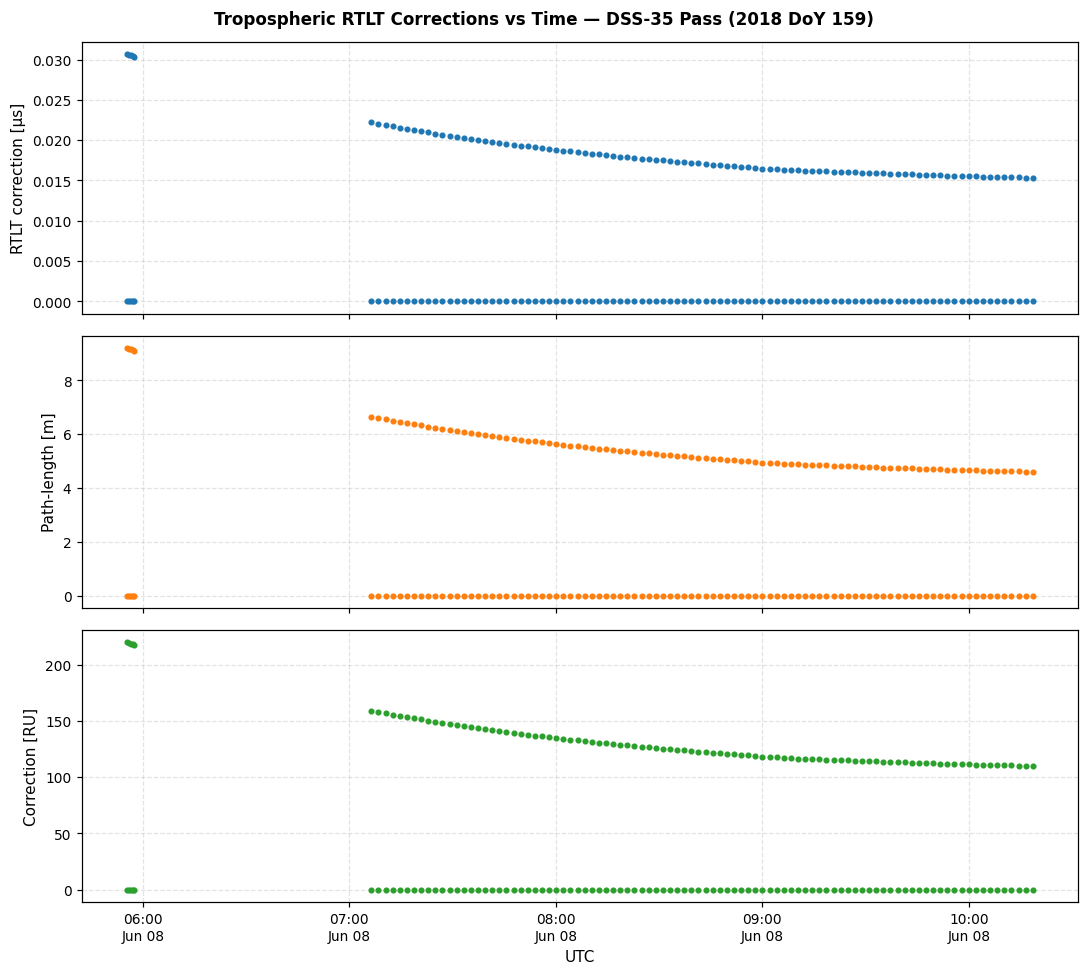

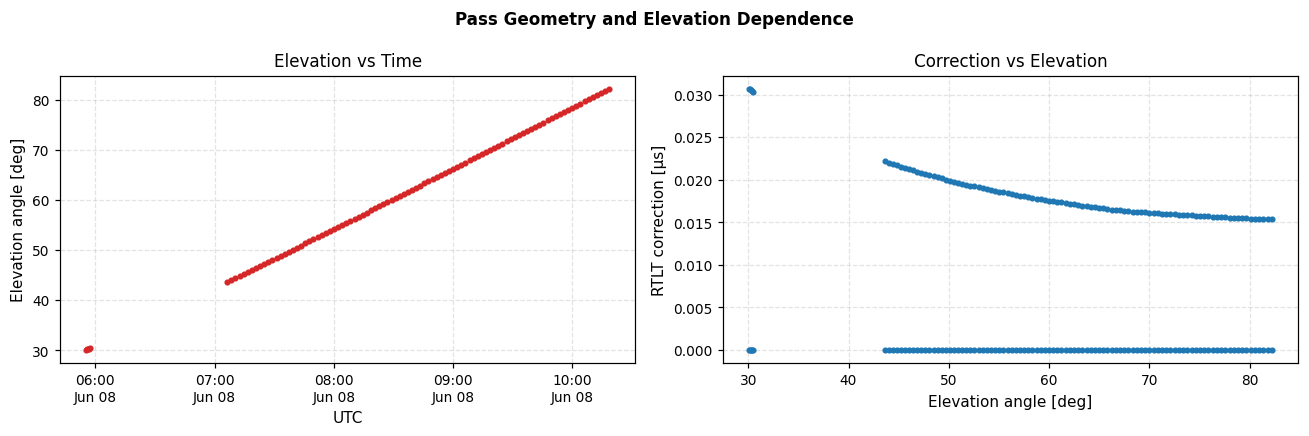

In [12]:
# Convert ET receive epochs to UTC datetimes
t_utc = et_to_utc(SRA_t3.times.values)

# ── Figure 1: corrections vs time (3 panels) ─────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
fig.suptitle("Tropospheric RTLT Corrections vs Time — DSS-35 Pass (2018 DoY 159)",
             fontweight="bold", fontsize=11)

axes[0].plot(t_utc, SRA_delta_rtlt * 1e6, "C0.", ms=6); axes[0].set_ylabel("RTLT correction [μs]")
axes[1].plot(t_utc, SRA_delta_m,           "C1.", ms=6); axes[1].set_ylabel("Path-length [m]")
axes[2].plot(t_utc, SRA_delta_RU,          "C2.", ms=6); axes[2].set_ylabel("Correction [RU]")
axes[2].set_xlabel("UTC")

for ax in axes:
    ax.grid(True, alpha=0.35, linestyle="--")
    fmt_cal(ax, fmt="%H:%M\n%b %d")

plt.tight_layout()
plt.show()

# ── Figure 2: geometry — elevation vs time, correction vs elevation ───────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Pass Geometry and Elevation Dependence", fontweight="bold", fontsize=11)

axes[0].plot(t_utc, SRA_elevation_angles, "C3.", ms=6)
axes[0].set_xlabel("UTC")
axes[0].set_ylabel("Elevation angle [deg]")
axes[0].set_title("Elevation vs Time")
axes[0].grid(True, alpha=0.35, linestyle="--")
fmt_cal(axes[0], fmt="%H:%M\n%b %d")

axes[1].plot(SRA_elevation_angles, SRA_delta_rtlt * 1e6, "C0.", ms=6)
axes[1].set_xlabel("Elevation angle [deg]")
axes[1].set_ylabel("RTLT correction [μs]")
axes[1].set_title("Correction vs Elevation")
axes[1].grid(True, alpha=0.35, linestyle="--")

plt.tight_layout()
plt.show()